## Load data

This dataset was generated from [LSA64](https://facundoq.github.io/datasets/lsa64/), which contains videos of isolated sign language. It is composed of 64 signs in Argentine Sign Language (LSA) repeated multiple times by different signers. For this dataset, the poses of the signers were extracted using [MediaPipe Holistic](https://ai.google.dev/edge/mediapipe/solutions/vision/holistic_landmarker?hl=es-419).

The data is split into train and test folders:

The **train** folder contains the following files:

- `labels.csv`: a CSV file containing the labels of the training data. The file has the following columns:
  - `ID`: the ID of the data sample.
  - `Label`: the label of the data sample.

- `poses/`: a folder containing the pose data of the training samples. The pose data is stored as NumPy arrays in the following format:
  - Shape: `(num_frames, num_keypoints, 3)`
  - `num_frames`: the number of frames in the pose data.
  - `num_keypoints`: the number of keypoints in the pose data.
  - `3`: the x, y, and confidence values of each keypoint.

The **test** folder contains a poses folder following the same structure as the train folder. The labels of these files are kept private and will be used for evaluation.

In [1]:
import os
import pandas as pd
import numpy as np


train_path = "data/train"

# Read train labels
train_labels_df = pd.read_csv(os.path.join(train_path, "labels.csv"))
train_labels = train_labels_df["Label"].values
train_labels_df.head()

,ID,Label
0,0,41
1,1,3
2,2,39
3,3,45
4,4,62


In [2]:
# Load train poses
train_poses = []
for id in train_labels_df["ID"]:
    pose = np.load(f"{train_path}/poses/{id}.npy")
    train_poses.append(pose)

print(
    f"Dataset contains {len(train_poses)} samples for training belonging to {len(set(train_labels))} classes."
)

Dataset contains 2560 samples for training belonging to 64 classes.


### Sample visualization

In [5]:
%matplotlib notebook

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation


def animate(
    pose,
    h: int = 4,
    w: int = 4,
    size=10,
):
    def get_update(scatter):
        def update(frame):
            # Reshape keypoints to have each pair (x, y) in a row
            x = pose[frame, :, 0]
            y = pose[frame, :, 1]
            scatter.set_offsets(np.array((x, y)).T)
            return (scatter,)

        return update

    fig, ax = plt.subplots(figsize=(h, w))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.invert_yaxis()  # Invert y-axis so origin is at top-left
    scatter = ax.scatter([], [], s=size)
    return FuncAnimation(
        fig, get_update(scatter), frames=len(pose), interval=50, blit=True
    )

In [13]:
from IPython.display import HTML
import random


rand_index = random.randint(0, len(train_poses))
pose = train_poses[rand_index]
anim = animate(pose)
HTML(anim.to_jshtml())

<IPython.core.display.Javascript object>

## Data processing

### Normalize video lenghts

In [14]:
def pad_poses(poses, max_frames):
    return [np.pad(p, ((0, max_frames - p.shape[0]), (0, 0), (0, 0))) for p in poses]


# check min and max frame amount of keypoints
min_frames = min(p.shape[0] for p in train_poses)
# an extra margin of 10 frames is added to the max_frames in case poses from test set have more frames
max_frames = max(p.shape[0] for p in train_poses) + 10
print(f"Min frames: {min_frames}, Max frames: {max_frames}")

# add padding to the end of each pose to make them all the same length
padded_poses = pad_poses(poses=train_poses, max_frames=max_frames)

Min frames: 16, Max frames: 210


In [15]:
anim = animate(padded_poses[rand_index])
HTML(anim.to_jshtml())

<IPython.core.display.Javascript object>

## Split data

We will generate a "test" set from our data available.

In [16]:
from sklearn.model_selection import train_test_split

y_train, y_test, x_train, x_test = train_test_split(
    train_labels,
    padded_poses,
    stratify=train_labels,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)
print(len(x_train), len(x_test))

2048 512


In [21]:
x_train_array = np.array(x_train)
y_train_array = np.array(y_train).reshape(-1, 1) - 1

print(f"Training set shape: {x_train_array.shape}")
print(f"Training labels shape: {y_train_array.shape}")

Training set shape: (2048, 210, 75, 3)
Training labels shape: (2048, 1)


## Model

### Definition

In [18]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    TimeDistributed,
    Flatten,
    Dropout,
    BatchNormalization,
    Conv1D,
    MaxPooling1D,
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2


input_shape = (max_frames, 75, 3)
inputs = Input(shape=input_shape)

# TimeDistributed layer applies the same operation to each frame along the time axis (expected input shape: batch, time, features)
x = TimeDistributed(Flatten())(inputs)

# A dense layer is applied to each frame, intended as encoder of each pose frame
x = TimeDistributed(Dense(128, activation="relu", kernel_regularizer=l2(1e-4)))(x)
x = TimeDistributed(BatchNormalization())(x)
x = TimeDistributed(Dropout(0.3))(x)

# A 1D convolutional layer is applied through the time axis to capture temporal patterns, looking at a window of 3 frames
x = Conv1D(128, kernel_size=3, activation="relu")(x)
x = MaxPooling1D(pool_size=2)(x)

# LSTM layers are used to capture temporal dependencies
x = LSTM(256, return_sequences=True)(x)
x = Dropout(0.5)(x)
x = LSTM(256, return_sequences=False)(x)
x = Dropout(0.5)(x)

# Output layer with as many units as classes and softmax activation for multi-class classification
outputs = Dense(len(set(train_labels)), activation="softmax")(x)

# Build model
model = Model(inputs=inputs, outputs=outputs)

2024-10-09 18:01:27.042032: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-09 18:01:27.042065: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-09 18:01:27.043323: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-09 18:01:27.049774: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-09 18:01:27.879083: W tensorflow/compiler/tf2

In [19]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 210, 75, 3)]      0         
                                                                 
 time_distributed (TimeDist  (None, 210, 225)          0         
 ributed)                                                        
                                                                 
 time_distributed_1 (TimeDi  (None, 210, 128)          28928     
 stributed)                                                      
                                                                 
 time_distributed_2 (TimeDi  (None, 210, 128)          512       
 stributed)                                                      
                                                                 
 time_distributed_3 (TimeDi  (None, 210, 128)          0         
 stributed)                                                  

In [26]:
model.predict(x_train_array[:1])

1/1 [==============================] - 0s 16ms/step


array([[0.015625  , 0.015625  , 0.015625  , 0.01562499, 0.01562501,
        0.01562501, 0.01562501, 0.015625  , 0.015625  , 0.015625  ,
        0.015625  , 0.015625  , 0.01562501, 0.015625  , 0.01562499,
        0.015625  , 0.015625  , 0.015625  , 0.015625  , 0.01562499,
        0.01562499, 0.01562502, 0.015625  , 0.015625  , 0.015625  ,
        0.015625  , 0.015625  , 0.015625  , 0.015625  , 0.015625  ,
        0.01562499, 0.015625  , 0.015625  , 0.015625  , 0.01562501,
        0.015625  , 0.015625  , 0.015625  , 0.01562501, 0.015625  ,
        0.015625  , 0.015625  , 0.01562498, 0.015625  , 0.015625  ,
        0.015625  , 0.01562499, 0.01562499, 0.015625  , 0.01562501,
        0.01562499, 0.015625  , 0.01562501, 0.015625  , 0.01562499,
        0.01562499, 0.015625  , 0.01562501, 0.015625  , 0.01562501,
        0.01562501, 0.015625  , 0.01562501, 0.015625  ]], dtype=float32)

### Training

In [28]:
from tensorflow.keras.callbacks import EarlyStopping


# Early Stopping callback to stop training when the validation loss does not improve
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

# Train model
history = model.fit(
    x_train_array,
    y_train_array,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
)

Epoch 1/30


2024-10-09 18:13:58.018296: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f01e04b8110 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-10-09 18:13:58.018318: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA TITAN X (Pascal), Compute Capability 6.1
2024-10-09 18:13:58.023941: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1728508438.096709  587097 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


52/52 [==============================] - 8s 46ms/step - loss: 4.2015 - accuracy: 0.0147 - val_loss: 4.1764 - val_accuracy: 0.0122
Epoch 2/30
52/52 [==============================] - 1s 17ms/step - loss: 4.1900 - accuracy: 0.0122 - val_loss: 4.1776 - val_accuracy: 0.0098
Epoch 3/30
52/52 [==============================] - 1s 17ms/step - loss: 4.1877 - accuracy: 0.0147 - val_loss: 4.1779 - val_accuracy: 0.0098
Epoch 4/30
52/52 [==============================] - 1s 17ms/step - loss: 4.1807 - accuracy: 0.0208 - val_loss: 4.1786 - val_accuracy: 0.0171
Epoch 5/30
52/52 [==============================] - 1s 19ms/step - loss: 4.1805 - accuracy: 0.0189 - val_loss: 4.1793 - val_accuracy: 0.0244
Epoch 6/30
52/52 [==============================] - 1s 16ms/step - loss: 4.1773 - accuracy: 0.0171 - val_loss: 4.1805 - val_accuracy: 0.0146
Epoch 7/30
52/52 [==============================] - 1s 17ms/step - loss: 4.1722 - accuracy: 0.0171 - val_loss: 4.1796 - val_accuracy: 0.0146
Epoch 8/30
52/52 [======

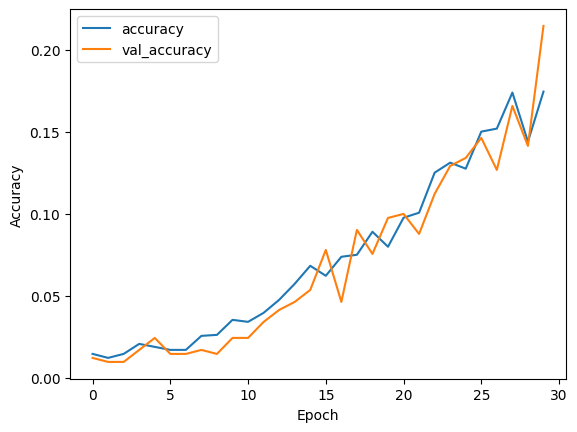

In [30]:
%matplotlib inline

# plot history
plt.figure()
plt.plot(history.history["accuracy"], label="accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Run model over test data

After training the model, we have to run it over the test set and submit the results.

In [31]:
# load test data
test_path = "data/test"
test_poses = []
ids = sorted([int(id.split(".")[0]) for id in os.listdir(f"{test_path}/poses")])
for id in ids:
    pose = np.load(f"{test_path}/poses/{id}.npy")
    test_poses.append(pose)
print(f"Dataset contains {len(test_poses)} samples for testing.")

Dataset contains 640 samples for testing.


In [35]:
# get results for test data
padded_test_poses = [
    np.pad(p, ((0, max_frames - p.shape[0]), (0, 0), (0, 0))) for p in test_poses
]
x_test_array = np.array(padded_test_poses)
y_pred = model.predict(x_test_array)
y_pred_array = np.argmax(y_pred, axis=1) + 1

20/20 [==============================] - 0s 7ms/step


In [38]:
len(y_pred_array)

640

In [37]:
# Store predictions in a CSV file to submit to the competition
pd.DataFrame({"ID": ids, "Label": y_pred_array}).to_csv("submission.csv", index=False)